In [15]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()




True

In [16]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [17]:
class State(TypedDict):
    topic: str
    advertisement: str
    review: str
    tagline: str
    combined_output: str
    image_url: str

In [18]:
def generate_advertisement(state: State) -> State:
    """Calls OpenAI API to generate an advertisement related to the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a creative AI that writes catchy advertisements."},
            {"role": "user", "content": f"Write a catchy advertisement for a product related to {state['topic']}."}
        ],
        max_tokens=200
    )
    advertisement = msg.choices[0].message.content.strip()
    return {"advertisement": advertisement}

In [19]:
# Step 4: Generate a product review
def generate_review(state: State):
    """Calls OpenAI API to generate a detailed product review for the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that writes detailed product reviews."},
            {"role": "user", "content": f"Write a product review for a product related to {state['topic']}. Include pros and cons."}
        ],
        max_tokens=300
    )
    review = msg.choices[0].message.content.strip()
    return {"review": review}

In [20]:
# Step 5: Generate a catchy tagline
def generate_tagline(state: State):
    """Calls OpenAI API to generate a catchy tagline for the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a creative AI that generates catchy taglines."},
            {"role": "user", "content": f"Create a short, catchy tagline for a product related to {state['topic']}."}
        ],
        max_tokens=50
    )
    tagline = msg.choices[0].message.content.strip()
    return {"tagline": tagline}


In [21]:
def combine_outputs(state: State):
    """Combines advertisement, review, and tagline into a single output."""
    combined = (
        f"Advertisement:\n{state['advertisement']}\n\n"
        f"Review:\n{state['review']}\n\n"
        f"Tagline:\n{state['tagline']}"
    )
    return {"combined_output": combined}

In [22]:
import base64
from pathlib import Path

def create_image(state: State) -> State:
    prompt = (
        f"Professional advertisement photo of {state['topic']}. "
        f"Clean background, marketing style. "
        f"Features: {state['combined_output'][:500]}"
    )


    # DALL·E 3 was retired in May 2026. GPT Image returns base64, not a hosted URL.
    response = client.images.generate(
        model="gpt-image-2",
        prompt=prompt,
        size="1024x1024",
        n=1,
    )
    
    image_b64 = response.data[0].b64_json
    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    image_path = images_dir / f"{state['topic'].lower().replace(' ', '_')}.png"
    image_path.write_bytes(base64.b64decode(image_b64))

    image_url = f"data:image/png;base64,{image_b64}"
    return {"image_url": image_url}
    

In [23]:
def build_workflow():
    """construct and compile the langgraph parallel workflow"""
    
    parallel_builder = StateGraph(State)
    parallel_builder.add_node("generate_advertisement", generate_advertisement)
    parallel_builder.add_node("generate_review", generate_review)
    parallel_builder.add_node("generate_tagline", generate_tagline)
    parallel_builder.add_node("combine_outputs", combine_outputs)
    parallel_builder.add_node("create_image", create_image)

    parallel_builder.add_edge(START, "generate_advertisement")
    parallel_builder.add_edge(START, "generate_review")
    parallel_builder.add_edge(START, "generate_tagline")

    parallel_builder.add_edge("generate_advertisement", "combine_outputs")
    parallel_builder.add_edge("generate_review", "combine_outputs")
    parallel_builder.add_edge("generate_tagline", "combine_outputs")
    parallel_builder.add_edge("combine_outputs", "create_image")
    parallel_builder.add_edge("create_image", END)

    return parallel_builder.compile()

In [24]:
parallel_workflow = build_workflow()

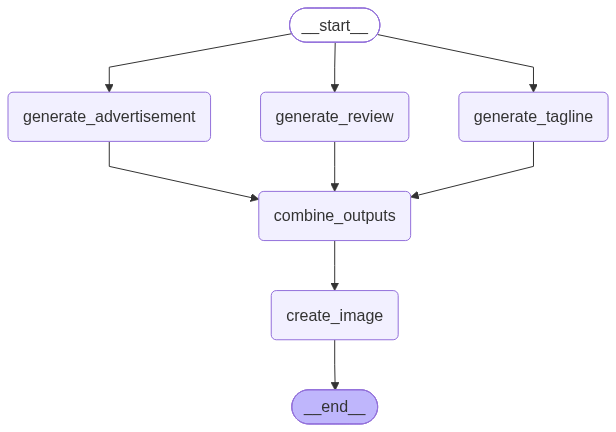

In [25]:

from IPython.display import Image, display

try:
    display(Image(parallel_workflow.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [26]:
topic = "smart home devices"
result = parallel_workflow.invoke({"topic": topic})

{'topic': 'smart home devices',
 'advertisement': '🌟 **Unlock the Future of Living with SmartNest!** 🏡✨\n\nImagine a home that thinks for you. With SmartNest Smart Home Devices, elevate your everyday routine into an extraordinary experience! \n\n🔥 **Why Choose SmartNest?**\n- **Your Home, Your Rules:** Control lighting, temperature, security, and more—all from the palm of your hand. \n- **Energy Efficient:** Save on bills while keeping cozy—SmartNest learns your habits and adjusts accordingly! \n- **Sleek Design:** Modern looks that fit seamlessly into any decor. Why sacrifice style for functionality? \n- **Voice-Activated Magic:** “Hey, SmartNest!” Let your voice command everything you need!\n\n💡 **Special Launch Offer!** 🎉 \nGet 20% OFF your first order and a FREE smart bulb when you sign up today!\n\nTransform your space into a sanctuary of convenience and comfort. Join the SmartNest revolution and experience the art of smart living! 🌐',
 'review': '**Product Review: Philips Hue Whi
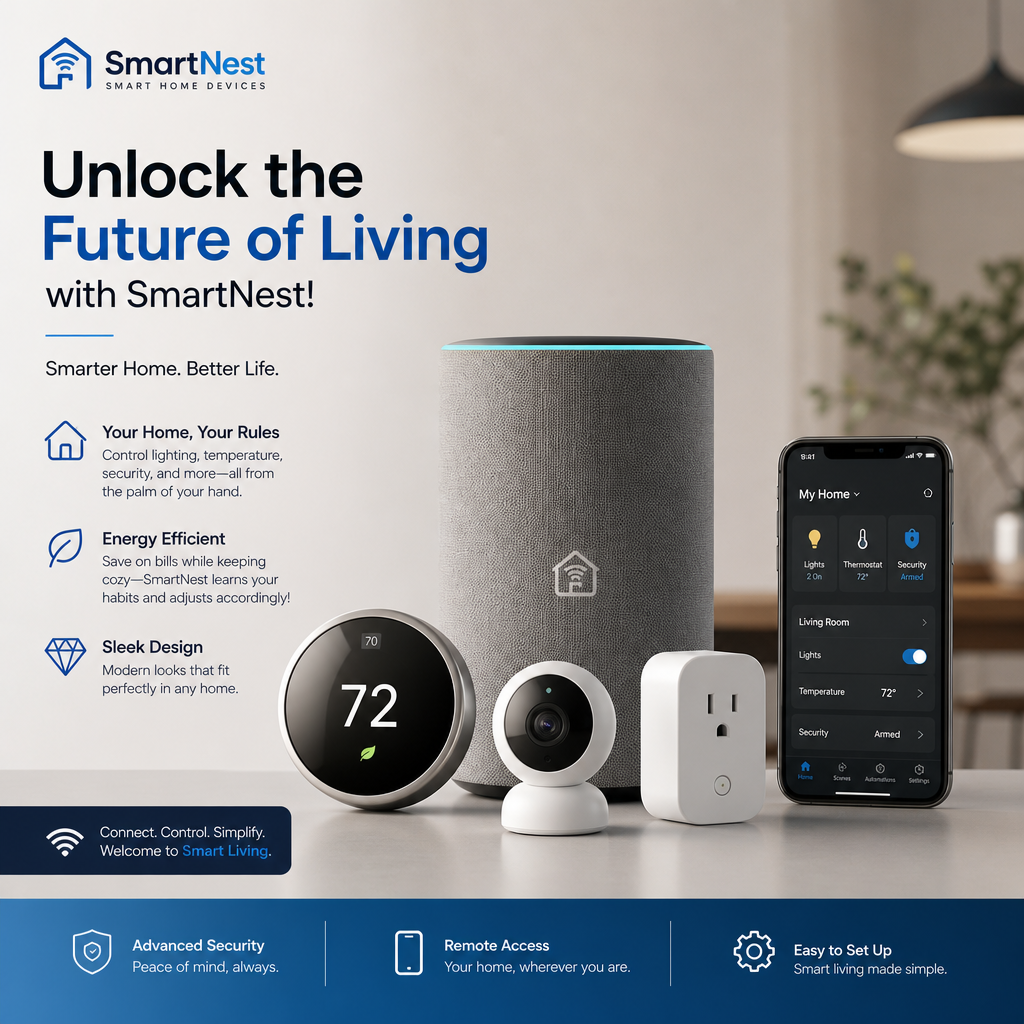

In [27]:
result